# First look into TiRex-2

In [2]:
import sys
sys.path.append('../tirex/src') # Add the path to the tirex module

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch

from tirex2 import load_model as load_model2
from tirex2 import TimeseriesType
from tirex import ForecastModel, load_model
from tirex.util import plot_forecast
from tirex2.plotting import plot_multivariate

# set default figure size for all plots
plt.rcParams["figure.figsize"] = (12, 6)

# Load data

Download the data from the notebook [data_download.ipynb](data_download.ipynb) before.

In [4]:
data_path_train = "../data/train.csv"
data_path_test = "../data/test.csv"
data_test = pl.read_csv(data_path_test, try_parse_dates=True)

number_series = len(data_test['series_index'].unique())
print(f"Number of time series in the test set: {number_series}")
data_test.head()

Number of time series in the test set: 361


timestamp,value,series_name,series_index
datetime[μs],f64,str,i64
2025-09-27 22:00:00,0.564,"""home_electricity""",0
2025-09-27 22:15:00,0.564,"""home_electricity""",0
2025-09-27 22:30:00,0.556,"""home_electricity""",0
2025-09-27 22:45:00,0.568,"""home_electricity""",0
2025-09-27 23:00:00,0.56,"""home_electricity""",0


# Load Model

In [20]:
model = load_model2("NX-AI/TiRex-2", device="cuda")
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {total_params:,}")
model

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Total Parameters: 82,501,744


# Prediction

Selected time series HU_solar_generation_actual_15 with index 50 and shape (7172,)


<Axes: >

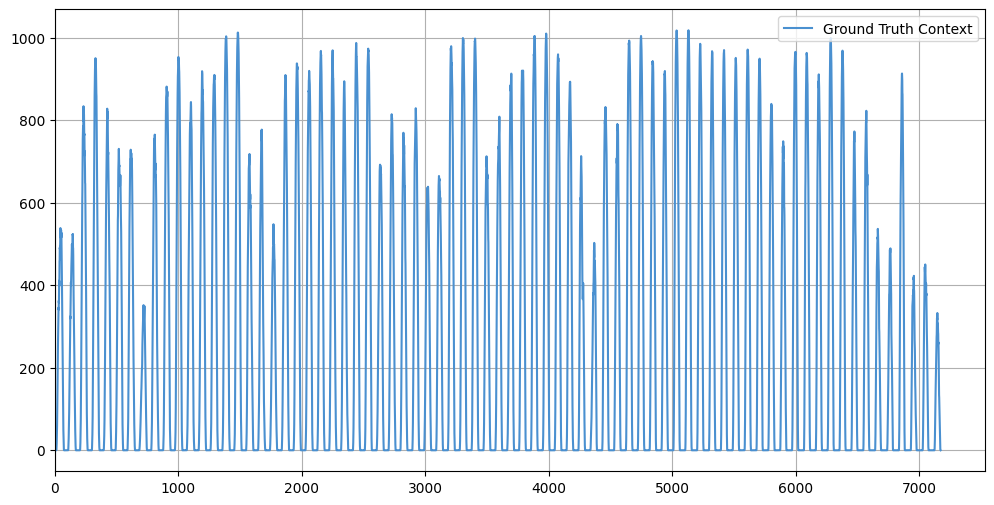

In [21]:
# select a single time series from the test data
idx_s = 50

df_s = data_test.filter(pl.col("series_index") == idx_s)
name_s = df_s.select(pl.col("series_name"))[0].item()
values_s = df_s.select(pl.col("value")).to_numpy().copy().reshape(-1) # copy to make it writeable for the model
print(f"Selected time series {name_s} with index {idx_s} and shape {values_s.shape}")
plot_forecast(values_s)

In [28]:
# set prediction length and starting point for prediction
prediction_length = 350
start_point = -1500

ctx_s, future_s = np.split(values_s, [start_point])
ctx_s.shape, future_s.shape

((5672,), (1500,))

In [29]:
# univariate time series
ts = TimeseriesType(target=torch.as_tensor(ctx_s, dtype=torch.float32).unsqueeze(0), past_covariates=None, future_covariates=None)

In [30]:
# multievariate test
ts_multivariate = TimeseriesType(
    target=torch.as_tensor([ctx_s, ctx_s], dtype=torch.float32),
    past_covariates=None,
    future_covariates=torch.rand((2, len(ctx_s)+prediction_length), dtype=torch.float32)
)

In [31]:
fc = model.forecast([ts], prediction_length=prediction_length)[0]

prediction_length=350 exceeds the supported maximum of 320. It will be truncated to 320.


In [32]:
fc.shape

torch.Size([1, 9, 320])

/tmp/ipykernel_61024/1820586669.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


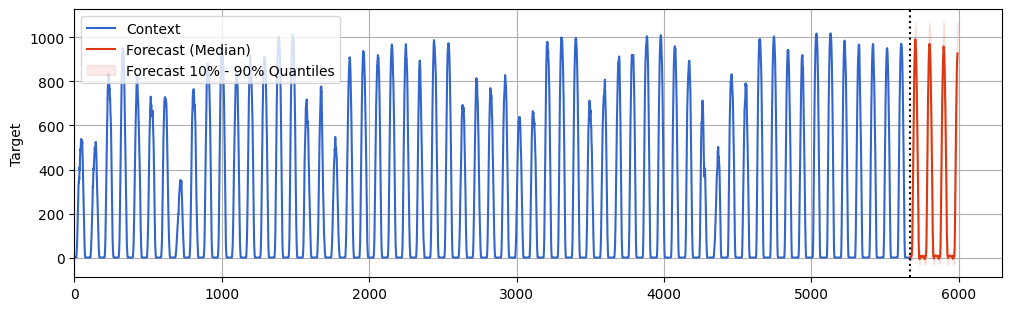

In [33]:
cap_input = -1000
#plot_forecast(ts.target[cap_input:], fc.numpy()[0], future_s)

fig = plot_multivariate(ts, fc, engine="matplotlib")
fig.show()

In [38]:
from tirex2.demo import Demo, plot_demo_forecast

In [39]:
demo = Demo.create_nonstationary_demo()

In [42]:
ts_multivariate = demo.to_timeseries_type(include_covariates=True)

In [50]:
ts_multivariate.future_covariates.shape

torch.Size([2, 582])